# Lab 6 Application

Build an end-to-end email workflow using the LangGraph ideas from the earlier labs.


In [1]:
from IPython.display import Image, display
from langgraph.checkpoint.memory import InMemorySaver

from langgraph_course.email_workflow import (
    EmailWorkflowSession,
    build_email_workflow,
    create_default_services,
)
from langgraph_course.email_workflow.langsmith import get_langsmith_config


In [2]:
from pprint import pformat
from textwrap import fill

from IPython.display import HTML

display(HTML("""
<style>
.jp-OutputArea-output pre {
    white-space: pre-wrap !important;
    word-break: break-word !important;
}
</style>
"""))

def show_state(state: dict, *, width: int = 88) -> None:
    def wrap_text(text: str) -> str:
        return "\n".join(
            fill(line, width=width, replace_whitespace=False)
            for line in text.splitlines()
        ) if text else ""

    for key, value in state.items():
        print(f"{key}:")
        if isinstance(value, str):
            print(wrap_text(value))
        else:
            print(pformat(value, width=width, sort_dicts=False))
        print()

In [ ]:
langsmith_config = get_langsmith_config()
print(langsmith_config.summary)
print(f"LangSmith project: {langsmith_config.project}")

if langsmith_config.tracing_active:
    print(
        "After running the billing scenario below, open LangSmith Studio and "
        "filter for source:notebook or workflow_name = email-agent."
    )
else:
    print(
        "LangSmith is disabled or incomplete. This notebook will still run "
        "fully in local-only mode."
    )


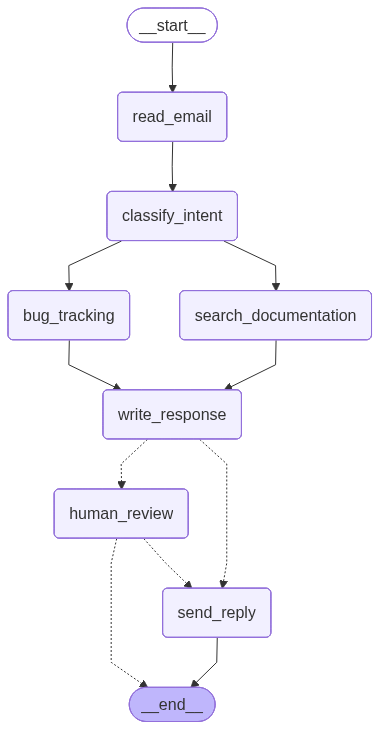

In [3]:
services = create_default_services()
app = build_email_workflow(services, checkpointer=InMemorySaver())
display(Image(app.get_graph().draw_mermaid_png()))


In [4]:
billing_session = EmailWorkflowSession(app, thread_id="billing-review")
billing_result = billing_session.start(
    email_content="I was charged twice for my subscription. Please fix this urgently.",
    sender_email="customer@example.com",
    email_id="email-billing-001",
    source="notebook",
)
show_state(billing_result)


Needs approval
email_content:
I was charged twice for my subscription. Please fix this urgently.

sender_email:
customer@example.com

email_id:
email-billing-001

normalized_email:
I was charged twice for my subscription. Please fix this urgently.

classification:
{'intent': 'billing',
 'urgency': 'high',
 'topic': 'duplicate charge on subscription',
 'summary': 'Customer reports being charged twice for their subscription and requests '
            'immediate resolution.'}

search_results:
['Billing duplicate charges: Apologize, confirm the duplicate charge review, and '
 'explain that billing corrections usually complete in 3-5 business days.',
 'Subscription renewal pricing: Renewal pricing depends on the customer tier and '
 'current plan. Avoid quoting a rate unless the pricing policy is available.',
 'Product defect escalation: For a broken or unsafe product, create a bug or defect '
 'ticket and reassure the customer that support is escalating the issue immediately.']

draft_resp

In [5]:
approved_result = billing_session.resume_review(
    approved=True,
    edited_response=(
        "We reviewed the duplicate charge, escalated it to billing, and will "
        "update you shortly."
    ),
    source="notebook",
)
show_state(approved_result)


Sending reply: We reviewed the duplicate charge, escalated it to billing, and will update you s...
email_content:
I was charged twice for my subscription. Please fix this urgently.

sender_email:
customer@example.com

email_id:
email-billing-001

normalized_email:
I was charged twice for my subscription. Please fix this urgently.

classification:
{'intent': 'billing',
 'urgency': 'high',
 'topic': 'duplicate charge on subscription',
 'summary': 'Customer reports being charged twice for their subscription and requests '
            'immediate resolution.'}

search_results:
['Billing duplicate charges: Apologize, confirm the duplicate charge review, and '
 'explain that billing corrections usually complete in 3-5 business days.',
 'Subscription renewal pricing: Renewal pricing depends on the customer tier and '
 'current plan. Avoid quoting a rate unless the pricing policy is available.',
 'Product defect escalation: For a broken or unsafe product, create a bug or defect '
 'ticket and r

In [6]:
question_session = EmailWorkflowSession(app, thread_id="question-direct")
question_result = question_session.start(
    email_content="Can you tell me how long the sale is on?",
    sender_email="customer@example.com",
    email_id="email-question-001",
    source="notebook",
)
show_state(question_result)


Sending reply: Subject: Re: Sale Duration Inquiry

Hi there,

Thank you for reaching out—we app...
email_content:
Can you tell me how long the sale is on?

sender_email:
customer@example.com

email_id:
email-question-001

normalized_email:
Can you tell me how long the sale is on?

classification:
{'intent': 'question',
 'urgency': 'low',
 'topic': 'sale/promotion duration inquiry',
 'summary': 'Customer is asking about the end date or remaining time of an ongoing '
            'sale promotion.'}

search_results:
['Promotion and sale timing: Sales windows may vary by region. Share the public end '
 'date only if it is listed in policy, otherwise explain that pricing can change '
 'without notice.',
 'Subscription renewal pricing: Renewal pricing depends on the customer tier and '
 'current plan. Avoid quoting a rate unless the pricing policy is available.',
 'Product color availability: Check live inventory before promising color '
 'availability. If a color is unavailable, offer to not